#### Training of 3 different models: DELFI (sequencing features), Proteomics, DELFI-Pro Lung (combined model)

In [1]:
#models
library(plyr)
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(devtools)
library(here)
library(rlucas)
library(reticulate)
#library(gbm)
library(cowplot)
library(FSelectorRcpp)
#library(janitor)
library(dplyr)
library(tidyr)

── Attaching core tidyverse packages ───────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ─────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::arrange()   masks plyr::arrange()
✖ purrr::compact()   masks plyr::compact()
✖ dplyr::count()     masks plyr::count()
✖ dplyr::desc()      masks plyr::desc()
✖ dplyr::failwith()  masks plyr::failwith()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::id()        masks plyr::id()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::mutate()    masks plyr::mutate()
✖ dplyr::rename()    masks plyr::rename()
✖ dplyr::summarise() masks plyr::summarise()
✖ dplyr::summarize() masks plyr::summarize()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become erro

## Step 1: Load feature dataframes

In [2]:
features_lucas_all <- read_csv("./features_lucas_all.csv")
features_train <- read_csv("./features_lucas_train.csv")
features_test <- read_csv("./features_lucas_test.csv")
features_mica_cal <- read_csv("./features_mica_calibration.csv")
features_mica_validation <- read_csv("./features_mica_validation.csv")



labels <- meta %>% select(id, assigned_group, Stage)
labels <- labels %>% filter(assigned_group != 1) %>%
    mutate(type = ifelse(assigned_group==2, "healthy", "cancer")) %>%
    select(-assigned_group)

meta_mica <- read_csv("../../data/mica_meta.csv", show_col_types=FALSE)

meta_mica <- meta_mica %>%
  mutate(Stage = ifelse(is.na(Stage), "NA", Stage))

# Filter out the MICA cohort and keep participants with no prior, baseline or future cancer
labels_mica <- meta_mica %>% select(id, Stage, assigned_group, 'Coded Type', type, 'CCI score', age, Smoking)

labels_mica <- labels_mica %>%
  mutate(Stage = ifelse(type == "healthy" & Stage != "NA", "NA", Stage))

labels_mica <- labels_mica %>%
  filter(assigned_group == 1 | `Coded Type` == 'Lung (LU)') %>%
  select(-assigned_group)

Rows: 209 Columns: 619
── Column specification ─────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (3): id, type, clinical_smokingstatus
dbl (616): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_con...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 144 Columns: 602
── Column specification ─────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): id, type
dbl (600): clinical_CEA, olink_IL8, olink_TNFRSF9, olink_TIE2, olink_MCP_3, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 65 Columns: 602
── Column specification ─────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): id, type
dbl (600): clin

## Step 2: Feature engineering 

### Literature Olink proteomic biomarkers

In [3]:
LC3_natcomms_2023 <- c('CFHR5','SPINT1','ALPP','ANGPT2','CASP-8','CDCP1','CEACAM5','CHI3L1','CXCL13','CXCL9','CXL17','EN-RAGE','GDF-15',
                       'HGF','IFI30','IGFBP-1','IGFBP-2','IL2-RA','IL6','LAMP3','MK','MMP12','MUC-16','OSM',
                       'S100A11','SCF','SFTPA1','SYND1','TFPI-2','TGF-alpha','TNFRSF6B','TNFSF13B', 'U-PAR', 'VEGFA', 'VWA1', 'WFDC2')


In [4]:
# Combine lists LC3_natcomms_2023 and Robbin_prog_transl_lung_cancer_2024, removing duplicates
validated <- unique(c(LC3_natcomms_2023))

# Create a vector of column names that match "olink_" followed by a protein in Robbins_validated
valid_olink_columns <- names(features_train)[names(features_train) %in% paste0("olink_", validated)]
valid_olink_columns

[1] "olink_IL6"    "olink_CXCL9"  "olink_HGF"    "olink_ANGPT2" "olink_LAMP3" 
[6] "olink_MMP12"  "olink_CXCL13" "olink_VEGFA"

In [5]:
# Specify whether a manual entry of proteins will be used for training or a PCA of all Olink 92 Immuno-Oncology panel

manual_protein_entry <- TRUE # or true

# Pass in the name of proteins to be included if manual_protein_entry = TRUE
important_proteins <- valid_olink_columns

## Step 3: Model Training on LUCAS Training Set

### Logistic Regression Models

In [6]:
# Model 1: DELFI base model using Z-score and PCA sequencing features
recipe_seq <- recipe(type ~ ., data=features_train) %>%
    step_rm(starts_with("clinical_"), starts_with("olink_")) %>%
    update_role(id, new_role = "ID") %>%
    step_pca(starts_with("ratio_"), prefix = "ratio_pc_",  threshold=0.90)  %>%
    step_corr(all_predictors(), threshold=0.95) %>%
    step_nzv(all_predictors())

# Model 2: DELFI base model using Z-score and PCA sequencing features, final protein panel
if (manual_protein_entry) {
    recipe_seq_olink <- recipe(type ~ ., data=features_train) %>%
        step_rm(starts_with("clinical_") & !any_of('clinical_CEA'), starts_with("olink_") & !any_of(important_proteins)) %>%
        update_role(id, new_role = "ID") %>%
        step_log(clinical_CEA) %>%
        step_pca(starts_with("ratio_"), prefix = "ratio_pc_",  threshold=0.90)  %>%
        #step_select_infgain(starts_with("olink_") | any_of('clinical_CEA'), outcome = "type", top_p = 4) %>%
        step_corr(all_predictors(), threshold=0.95) %>%
        step_nzv(all_predictors())
} else {
    recipe_seq_olink <- recipe(type ~ ., data = features_train) %>%
        step_rm(starts_with("clinical_") & !any_of('clinical_CEA')) %>%
        update_role(id, new_role = "ID") %>%
        step_log(clinical_CEA) %>%
        step_pca(starts_with("ratio_"), prefix = "ratio_pc_", threshold = 0.90) %>%
       #step_select_infgain(starts_with("olink_") | any_of('clinical_CEA'), outcome = "type", top_p = 4) %>%
        step_corr(all_predictors(), threshold = 0.95) %>%
        step_nzv(all_predictors())
}

# Model 3: Only Olink protein features
if (manual_protein_entry) {
    recipe_olink_only <- recipe(type ~ ., data=features_train) %>%
        step_rm(starts_with("clinical_") & !any_of('clinical_CEA'), starts_with("ratio_"), starts_with("zscore"), 
                starts_with("olink_") & !any_of(important_proteins)) %>%
        step_log(clinical_CEA) %>%
        update_role(id, new_role = "ID") %>%
        step_corr(all_predictors(), threshold=0.95) %>%
        step_nzv(all_predictors())
} else {
    recipe_olink_only <- recipe(type ~ ., data=features_train) %>%
        step_rm(starts_with("clinical_") & !any_of('clinical_CEA'), starts_with("ratio_"), starts_with("zscore")) %>%
        step_log(clinical_CEA) %>%
        update_role(id, new_role = "ID") %>%
        step_corr(all_predictors(), threshold=0.95) %>%
        step_nzv(all_predictors())
}

glmnetGrid <- expand.grid(
    alpha = 1,
    lambda = 10^seq(-5, -1, length.out = 100))


#### Logistic Regression

In [7]:
#### Train models
set.seed(1234)
ctrl <- trainControl(method = "repeatedcv",
                     number = 5,
                     repeats = 10,
                     verboseIter = FALSE,
                     savePredictions="final",
                     classProbs=TRUE,
                     index=createMultiFolds(features_train$type, 5, 10),
                     summaryFunction = twoClassSummary)

model_seq <- caret::train(recipe_seq,
                          data = features_train,
                          method = "glmnet",
                          tuneGrid = glmnetGrid,
                          trControl = ctrl,
                          metric="ROC")

model_seq_olink <- caret::train(recipe_seq_olink,
                          data = features_train,
                          method = "glmnet",
                          tuneGrid = glmnetGrid,
                          trControl = ctrl,
                          metric="ROC")

model_olink_only <- caret::train(recipe_olink_only,
                          data = features_train,
                          method = "glmnet",
                          tuneGrid = glmnetGrid,
                          trControl = ctrl,
                          metric="ROC")


Loading required namespace: glmnet

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8

Warning message:
“from glmnet C++ code (error code -70); Convergence for 70th lambda value not reached after maxit=100000 iterations; solutions for larger lambdas returned”


#### Step 4: Make and save predictions

In [8]:
### Results (Training Set Evaluation)
features_train <- features_train %>% mutate(rowIndex = seq_len(nrow(.)))
ids <- inner_join(features_train %>% select(id, rowIndex), labels, by="id")

# Apply DELFI base seq model to make predictions
pred.seq <- model_seq$pred
pred.seq <- pred.seq %>%
    group_by(rowIndex) %>%
    summarize(score.seq = mean(cancer))  # Ensure 'cancer' is the correct column for positive class prob

# Apply DELFI-olink seq model to make predictions
pred.seq.olink <- model_seq_olink$pred
pred.seq.olink <- pred.seq.olink %>%
    group_by(rowIndex) %>%
    summarize(score.seq.olink = mean(cancer))

# Apply Only Olink model to make predictions
pred.olink.only <- model_olink_only$pred
pred.olink.only <- pred.olink.only %>%
    group_by(rowIndex) %>%
    summarize(score.olink.only = mean(cancer))

# Merge Predictions
preds <- inner_join(pred.seq, pred.seq.olink, by="rowIndex")
preds <- inner_join(preds, pred.olink.only, by="rowIndex")
preds <- inner_join(ids, preds, by="rowIndex")
preds <- preds %>% select(-rowIndex)

# Display Results
preds


id,Stage,type,score.seq,score.seq.olink,score.olink.only
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
PGDX26721P,NA,healthy,0.53858183,0.230693278,0.1102104
PGDX26615P,III,cancer,0.88106219,0.970586118,0.7416265
PGDX26633P,IV,cancer,0.85156091,0.999428425,0.8819155
PGDX26648P,IV,cancer,1.00000000,1.000000000,0.9520637
PGDX26665P,NA,healthy,0.62519507,0.250035286,0.3355087
PGDX26856P,NA,healthy,0.66877050,0.640995884,0.3200315
PGDX26664P,I,cancer,0.19350610,0.105616947,0.2184890
PGDX26893P,NA,healthy,0.58015961,0.321680879,0.1600374
PGDX26938P,NA,healthy,0.14015920,0.039259378,0.2134046


#### Step 5: ROC AUC curves

Setting levels: control = cancer, case = healthy

Setting direction: controls > cases

Setting levels: control = cancer, case = healthy

Setting direction: controls > cases

Setting levels: control = cancer, case = healthy

Setting direction: controls > cases



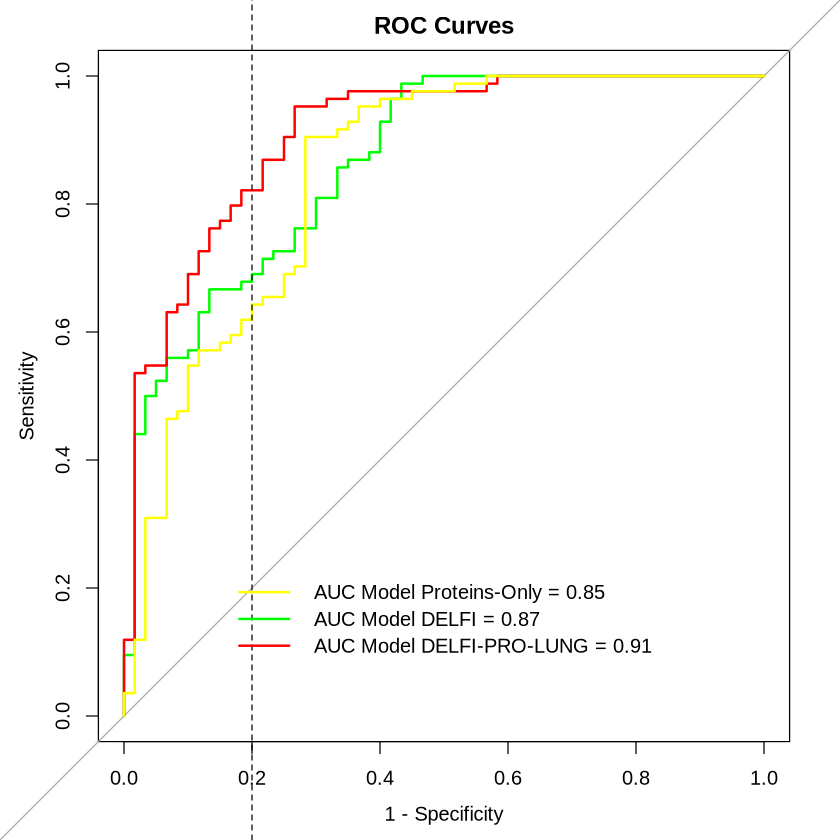

In [9]:
# Calculate and plot ROC curves
roc_curve_seq <- roc(preds$type, preds$score.seq)
roc_curve_seq_olink <- roc(preds$type, preds$score.seq.olink)
roc_curve_olink_only <- roc(preds$type, preds$score.olink.only)

# Adjust the margin space to avoid cutting off the legend
par(mar = c(5, 4, 4, 10) + 0.1, xpd = TRUE) # Increase right margin and allow clipping

# Plot ROC curves
plot(roc_curve_seq, main = "ROC Curves", col = "green", legacy.axes = TRUE)
lines(roc_curve_seq_olink, col = "red")
lines(roc_curve_olink_only, col = "yellow")

# Add vertical dotted line at x = 0.8
abline(v = 0.8, lty = 2, col = "black")

# Display AUC values
auc_seq <- auc(roc_curve_seq)
auc_seq_olink <- auc(roc_curve_seq_olink)
auc_olink_only <- auc(roc_curve_olink_only)

# Add legend for AUC values
legend("bottom", inset = c(-0.1, 0.1), legend = c(
    paste("AUC Model Proteins-Only =", round(auc_olink_only, 2)),
    paste("AUC Model DELFI =", round(auc_seq, 2)),
    paste("AUC Model DELFI-PRO-LUNG =", round(auc_seq_olink, 2))
), col = c("yellow", "green", "red"), lwd = 2, bty = "n")


## Step 4: Feature importance analysis

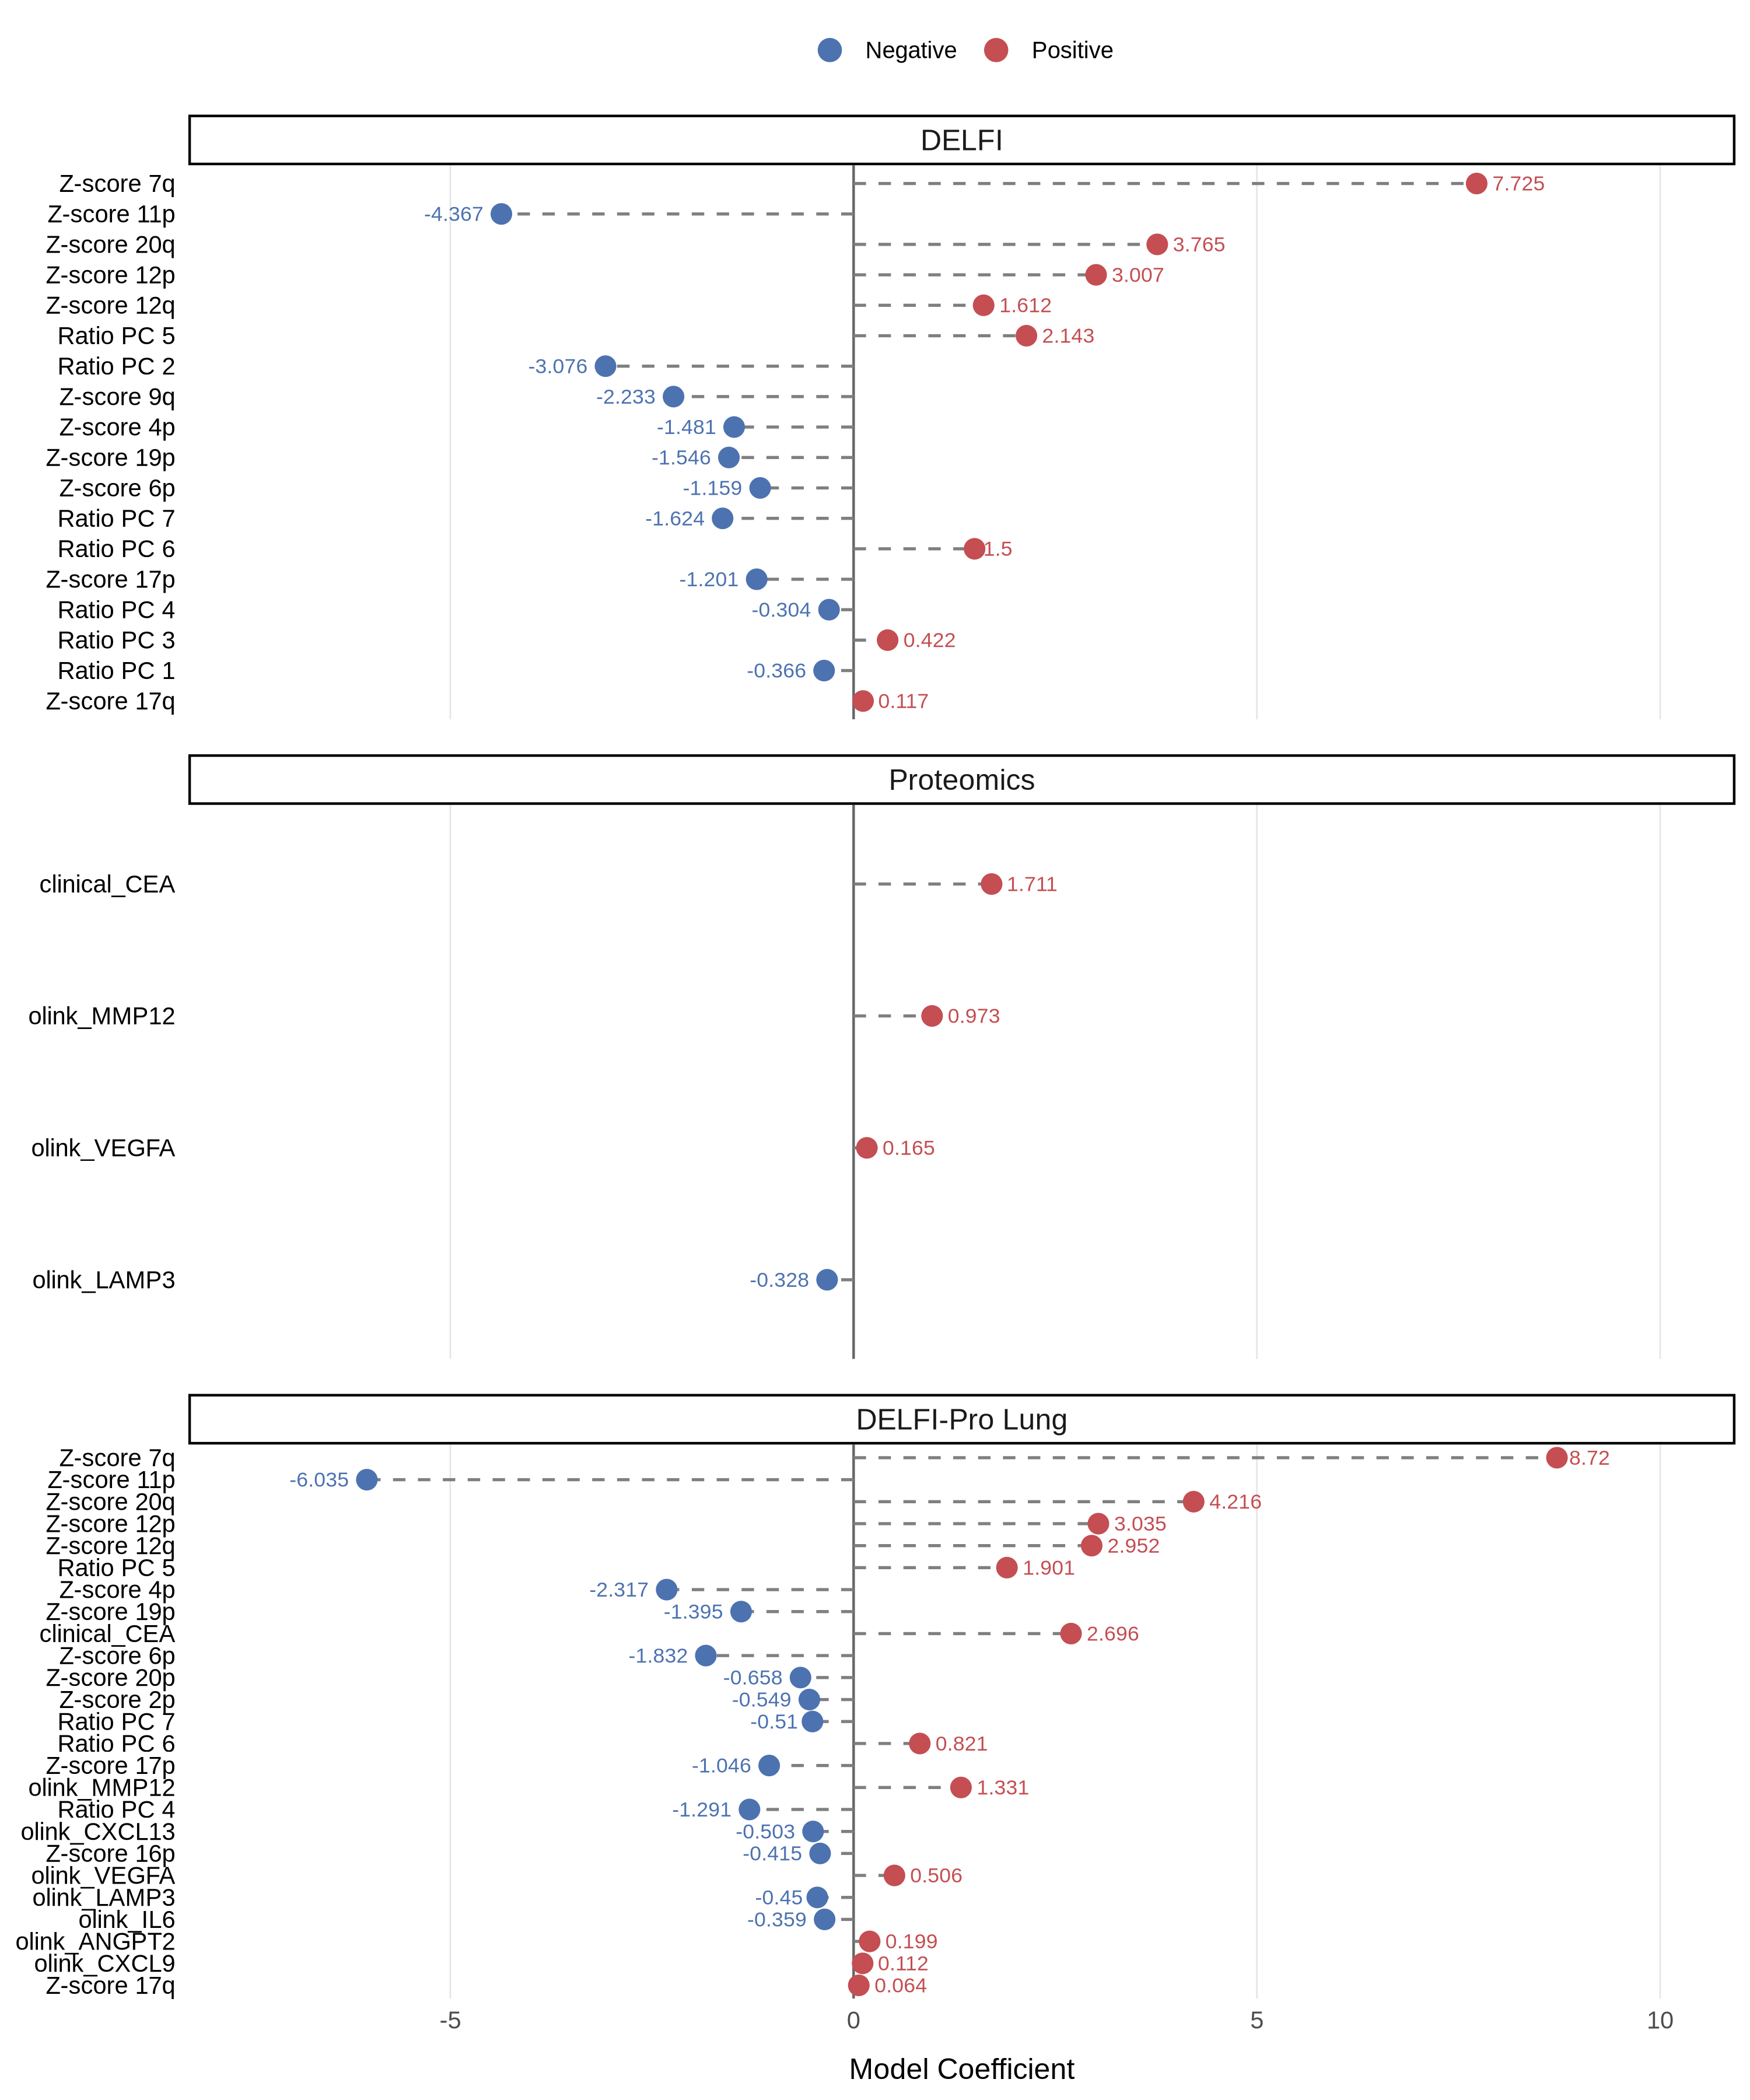

In [10]:
# ============================================================
# TOP 10 FEATURE IMPORTANCE - THREE MODELS
# ============================================================

# ============================================================
# FUNCTION TO EXTRACT SCALED COEFFICIENTS FROM A MODEL
# ============================================================

extract_scaled_coefs <- function(model, model_name) {
  # Flip coefficients so positive = more cancer-like
  orig_coefs <- coef(model$finalModel, s = model$bestTune$lambda) * (-1)
  
  # Prep recipe and get training data
  pr <- prep(model$recipe)
  traindat <- model$trainingData %>%
    mutate(id = factor(id),
           type = factor(type))
  model_input <- bake(pr, new_data = traindat)
  
  # Calculate feature standard deviations
  feature_sds <- model_input %>%
    dplyr::select(-c(id, type)) %>%
    as.data.frame() %>%
    summarise_all(sd)
  
  # Create coefficient dataframe with scaling
  feature_coefs <- data.frame(
    feature = names(feature_sds),
    sd = as.numeric(feature_sds)
  )
  feature_coefs <- merge(
    feature_coefs,
    data.frame(feature = rownames(orig_coefs),
               orig_coefs = as.numeric(orig_coefs)),
    by = 'feature', all.x = TRUE
  )
  feature_coefs$scaled_coefs <- feature_coefs$orig_coefs * feature_coefs$sd
  
  # Clean up and add model name
  feature_coefs %>%
    as_tibble() %>%
    filter(!is.na(scaled_coefs), scaled_coefs != 0) %>%
    mutate(
      model = model_name,
      importance = abs(scaled_coefs),
      # Clean feature labels
      feature_label = case_when(
        str_detect(feature, "^ratio_pc_") ~ gsub("ratio_pc_0?", "Ratio PC ", feature),
        str_detect(feature, "^zscore_") ~ gsub("zscore_", "Z-score ", feature),
        TRUE ~ feature
      )
    ) %>%
    arrange(desc(importance)) %>%
    slice_head(n = 25)
}

# ============================================================
# EXTRACT TOP 10 FROM EACH MODEL
# ============================================================

coefs_delfi <- extract_scaled_coefs(model_seq, "DELFI")
coefs_proteomics <- extract_scaled_coefs(model_olink_only, "Proteomics")
coefs_delfi_pro <- extract_scaled_coefs(model_seq_olink, "DELFI-Pro Lung")

# Combine all
all_coefs <- bind_rows(coefs_delfi, coefs_proteomics, coefs_delfi_pro) %>%
  mutate(
    model = factor(model, levels = c("DELFI", "Proteomics", "DELFI-Pro Lung")),
    direction = ifelse(scaled_coefs >= 0, "Positive", "Negative")
  )

# Within each model, rank by importance (descending) for y-axis ordering
all_coefs <- all_coefs %>%
  group_by(model) %>%
  arrange(importance) %>%
  mutate(y_pos = row_number()) %>%
  ungroup()

# ============================================================
# CREATE THE PLOT
# ============================================================

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 300)

p <- ggplot(all_coefs, aes(x = scaled_coefs, y = reorder(feature_label, y_pos))) +
  # Vertical reference line at 0
  geom_vline(xintercept = 0, color = "gray40", linewidth = 0.5) +
  
  # Lollipop stems (dashed)
  geom_segment(
    aes(x = 0, xend = scaled_coefs, yend = reorder(feature_label, y_pos)),
    color = "grey50",
    linewidth = 0.6,
    linetype = "dashed"
  ) +
  
  # Lollipop heads
  geom_point(
    aes(color = direction),
    size = 3.5
  ) +
  
  # Coefficient labels
  geom_text(
    aes(label = round(scaled_coefs, 3), 
        hjust = ifelse(scaled_coefs >= 0, -0.3, 1.3),
        color = direction),
    size = 3,
    show.legend = FALSE
  ) +
  
  # Colors
  scale_color_manual(
    values = c("Positive" = "#C44E52", "Negative" = "#4C72B0"),
    name = NULL
  ) +
  
  # Facet by model
  facet_wrap(~ model, ncol = 1, scales = "free_y") +
  
  # Expand x-axis to make room for labels
  scale_x_continuous(expand = expansion(mult = c(0.15, 0.15))) +
  
  labs(
    x = "Model Coefficient",
    y = NULL
  ) +
  
  theme_minimal(base_size = 12) +
  theme(
    # Facet strips
    strip.background = element_rect(color = "black", fill = "white", linewidth = 1),
    strip.text = element_text(size = 12, face = "plain"),
    
    # Panel
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_line(color = "grey90", linewidth = 0.3),
    panel.spacing = unit(1, "lines"),
    
    # Axes
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(size = 10),
    axis.title.x = element_text(size = 12, margin = margin(t = 10)),
    
    # Legend
    legend.position = "top",
    legend.justification = "center"
  ) +
  
  guides(color = guide_legend(override.aes = list(size = 4)))

print(p)

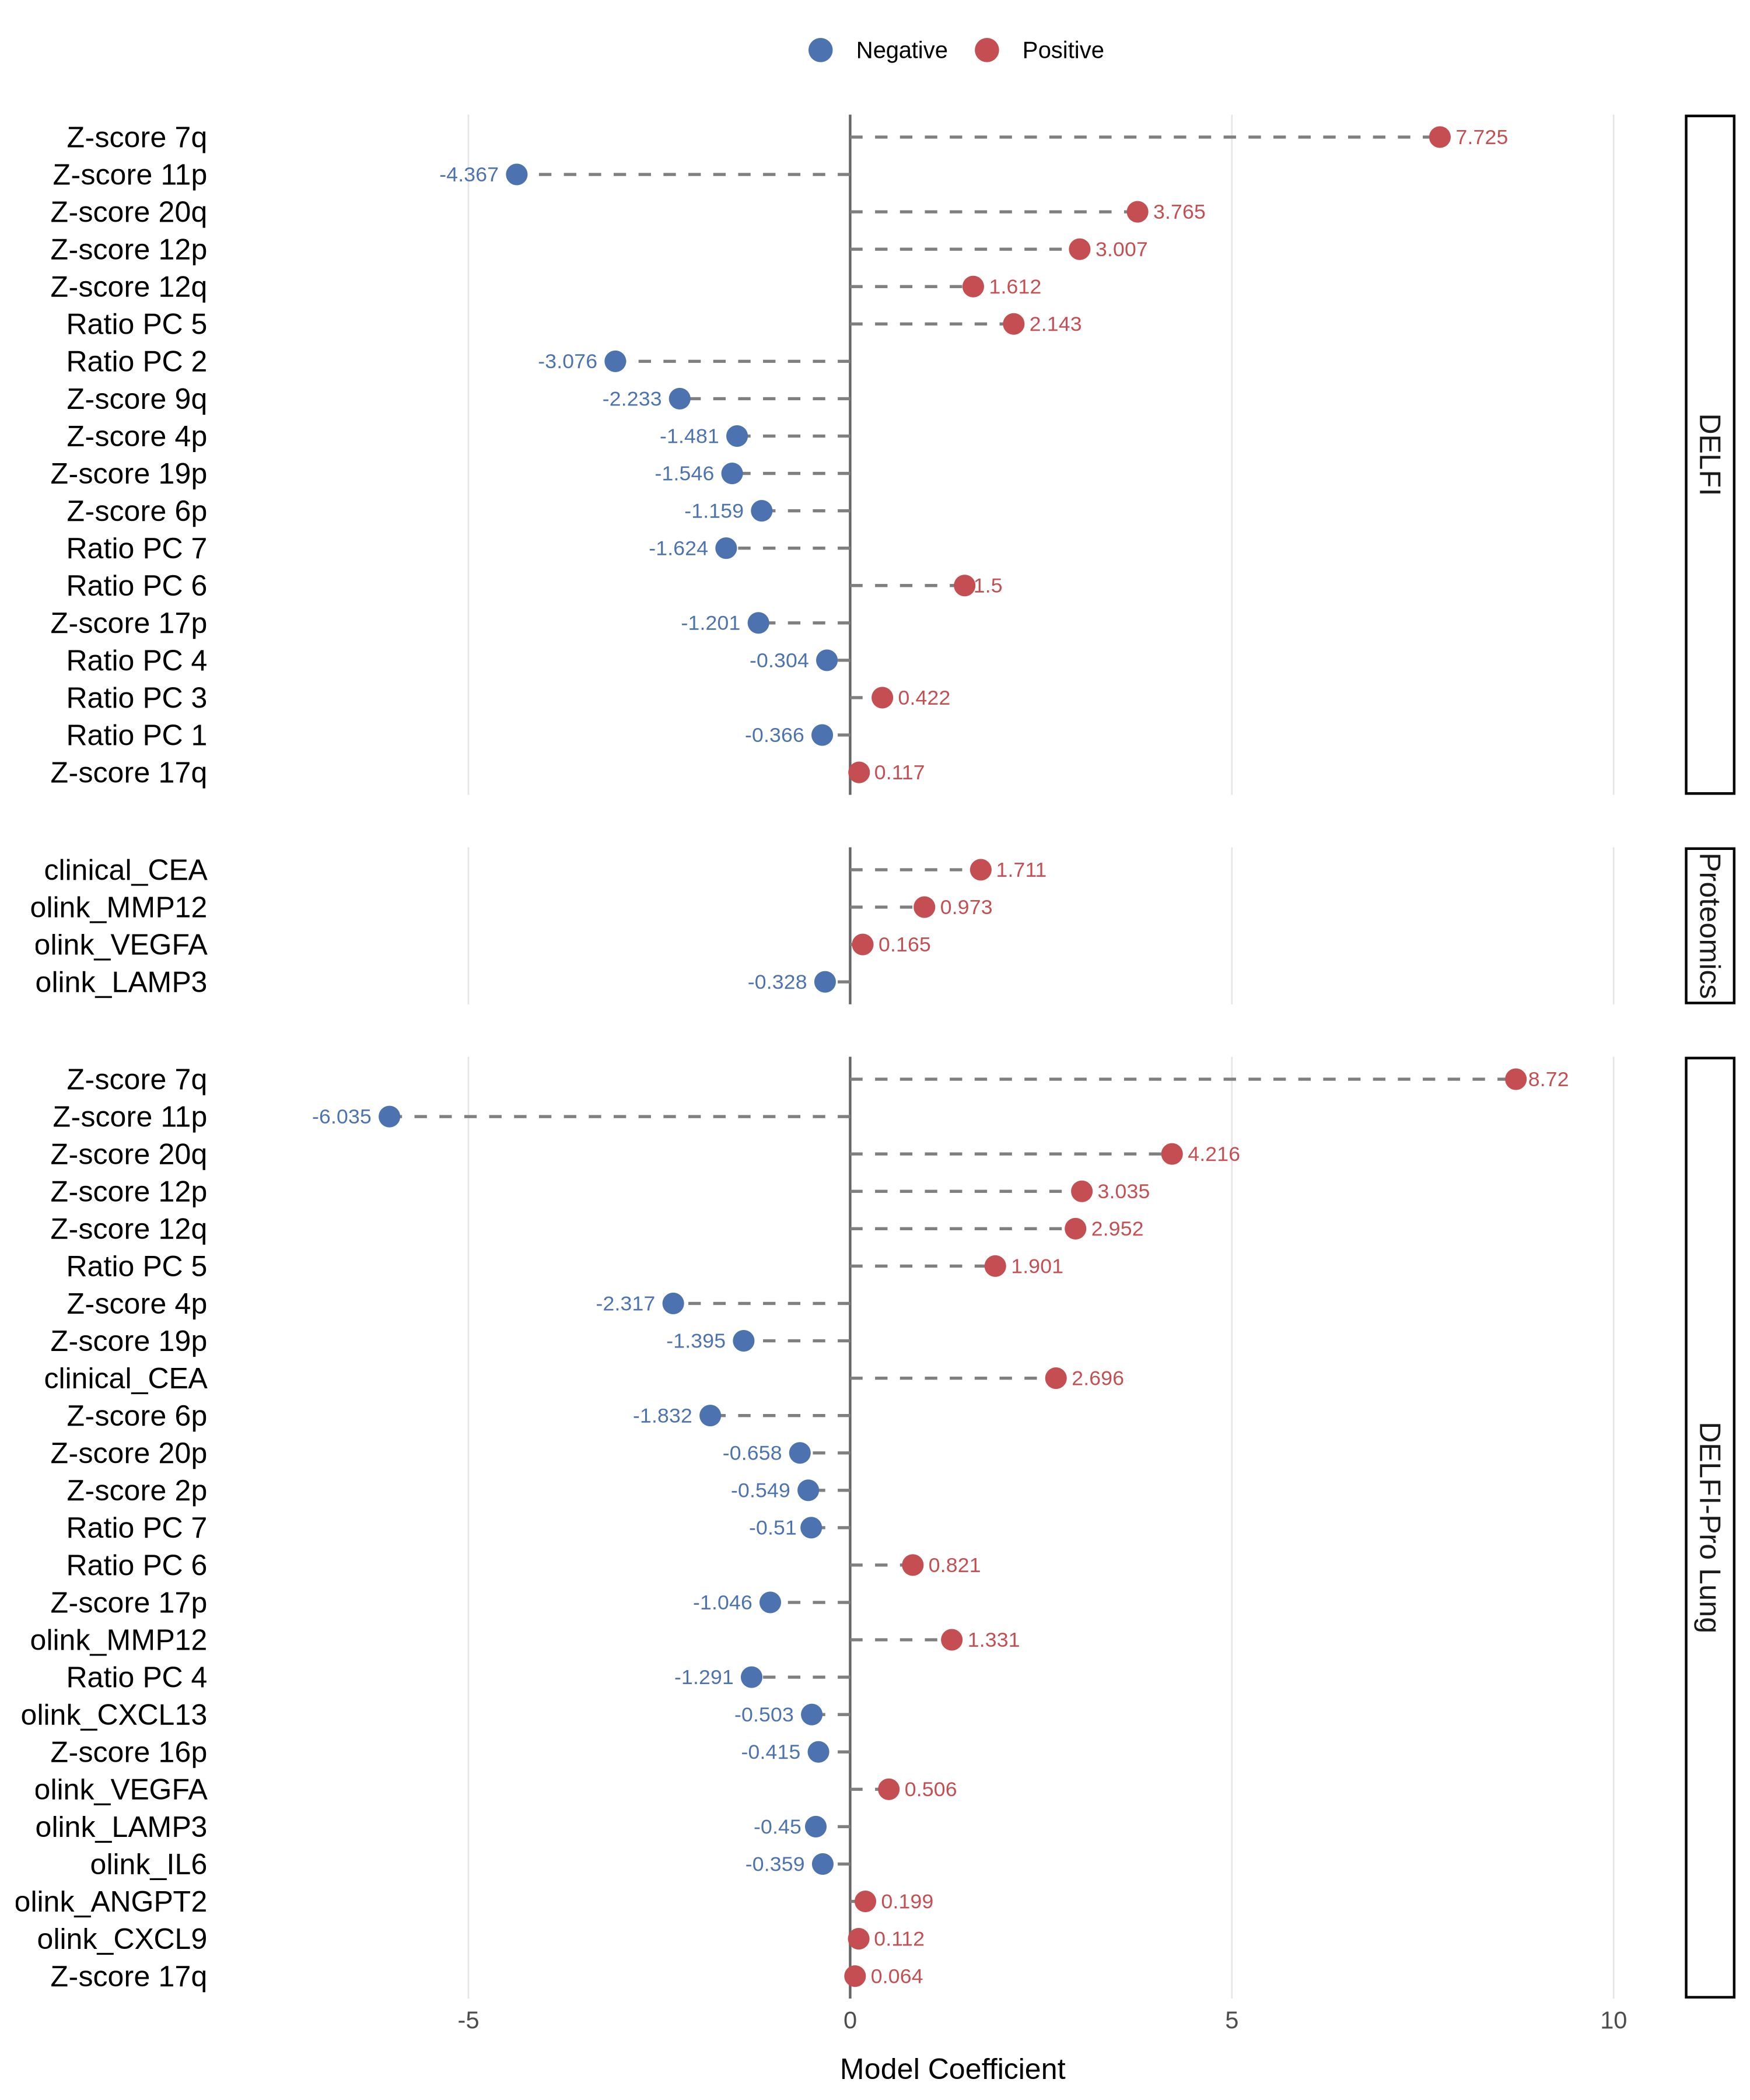

In [11]:
# ============================================================
# CREATE THE PLOT
# ============================================================

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 300)

p <- ggplot(all_coefs, aes(x = scaled_coefs, y = reorder(feature_label, y_pos))) +
  # Vertical reference line at 0
  geom_vline(xintercept = 0, color = "gray40", linewidth = 0.5) +
  
  # Lollipop stems (dashed)
  geom_segment(
    aes(x = 0, xend = scaled_coefs, yend = reorder(feature_label, y_pos)),
    color = "grey50",
    linewidth = 0.6,
    linetype = "dashed"
  ) +
  
  # Lollipop heads
  geom_point(
    aes(color = direction),
    size = 3.5
  ) +
  
  # Coefficient labels
  geom_text(
    aes(label = round(scaled_coefs, 3), 
        hjust = ifelse(scaled_coefs >= 0, -0.3, 1.3),
        color = direction),
    size = 3,
    show.legend = FALSE
  ) +
  
  # Colors
  scale_color_manual(
    values = c("Positive" = "#C44E52", "Negative" = "#4C72B0"),
    name = NULL
  ) +
  
  # Switch to facet_grid to enable space = "free_y" 
  # This sizes each panel proportionally to the number of rows it contains,
  # eliminating the excess whitespace in panels with fewer features
  facet_grid(model ~ ., scales = "free_y", space = "free_y") +
  
  # Expand x-axis to make room for labels
  scale_x_continuous(expand = expansion(mult = c(0.15, 0.15))) +
  
  labs(
    x = "Model Coefficient",
    y = NULL
  ) +
  
  theme_minimal(base_size = 12) +
  theme(
    # Facet strips
    strip.background = element_rect(color = "black", fill = "white", linewidth = 1),
    strip.text = element_text(size = 12, face = "plain"),
    
    # Panel
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_line(color = "grey90", linewidth = 0.3),
    panel.spacing = unit(1.5, "lines"),   # slightly more breathing room between panels
    
    # Axes
    axis.text.y = element_text(size = 12, color = "black"),   # increased from 10 → 12
    axis.text.x = element_text(size = 10),
    axis.title.x = element_text(size = 12, margin = margin(t = 10)),
    
    # Legend
    legend.position = "top",
    legend.justification = "center"
  ) +
  
  guides(color = guide_legend(override.aes = list(size = 4)))

print(p)

### Step 6: LUCAS Test Set Predictions

In [13]:
### Results for Test Set
features_test <- features_test %>% mutate(rowIndex = seq_len(nrow(.)))
ids_test <- inner_join(features_test %>% select(id, rowIndex), labels, by="id")

# Apply DELFI base seq model
pred.seq.test <- predict(model_seq, newdata = features_test, type = "prob")
pred.seq.test <- data.frame(rowIndex = features_test$rowIndex, 
                            score.seq.test = pred.seq.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.seq.test = mean(score.seq.test))

# Apply DELFI-olink seq model
pred.seq.olink.test <- predict(model_seq_olink, newdata = features_test, type = "prob")
pred.seq.olink.test <- data.frame(rowIndex = features_test$rowIndex, 
                                  score.seq.olink.test = pred.seq.olink.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.seq.olink.test = mean(score.seq.olink.test))

# Apply Only Olink model
pred.olink.only.test <- predict(model_olink_only, newdata = features_test, type = "prob")
pred.olink.only.test <- data.frame(rowIndex = features_test$rowIndex, 
                                   score.olink.only.test = pred.olink.only.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.olink.only.test = mean(score.olink.only.test))


# Merge predictions
preds_test <- inner_join(pred.seq.test, pred.seq.olink.test, by="rowIndex")
preds_test <- inner_join(preds_test, pred.olink.only.test, by="rowIndex")
preds_test <- inner_join(ids_test, preds_test, by="rowIndex")
preds_test <- preds_test %>% select(-rowIndex)

# Display Results
preds_test


id,Stage,type,score.seq.test,score.seq.olink.test,score.olink.only.test
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
PGDX26551P1,NA,healthy,0.06916648,0.06360356,0.15760038
PGDX26758P1,NA,healthy,0.10312696,0.03581940,0.30146330
PGDX26822P,NA,healthy,0.24750568,0.72851531,0.49607275
PGDX26680P,IV,cancer,1.00000000,1.00000000,0.99879534
PGDX26813P1,I,cancer,0.24498262,0.20919285,0.24250072
PGDX26924P,NA,healthy,0.13592498,0.06728364,0.29876848
PGDX26774P,NA,healthy,0.38612614,0.73525785,0.40431972
PGDX26696P,III,cancer,0.26492559,0.08174264,0.18936870
PGDX26786P,III,cancer,0.89381110,0.92812320,0.43604039


### Step 7: MICA Calibration Set Predictions

In [14]:
features_mica_cal <- features_mica_cal %>% mutate(rowIndex = seq_len(nrow(.)))
ids_test <- inner_join(features_mica_cal %>% select(id, rowIndex), labels_mica, by="id")

# Apply DELFI base seq model
pred.seq.test <- predict(model_seq, newdata = features_mica_cal, type = "prob")
pred.seq.test <- data.frame(rowIndex = features_mica_cal$rowIndex, 
                            score.seq.test = pred.seq.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.seq.test = mean(score.seq.test))

# Apply DELFI-olink seq model
pred.seq.olink.test <- predict(model_seq_olink, newdata = features_mica_cal, type = "prob")
pred.seq.olink.test <- data.frame(rowIndex = features_mica_cal$rowIndex, 
                                  score.seq.olink.test = pred.seq.olink.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.seq.olink.test = mean(score.seq.olink.test))

# Apply Only Olink model
pred.olink.only.test <- predict(model_olink_only, newdata = features_mica_cal, type = "prob")
pred.olink.only.test <- data.frame(rowIndex = features_mica_cal$rowIndex, 
                                   score.olink.only.test = pred.olink.only.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.olink.only.test = mean(score.olink.only.test))


# Merge predictions
preds_mica_cal <- inner_join(pred.seq.test, pred.seq.olink.test, by="rowIndex")
preds_mica_cal <- inner_join(preds_mica_cal, pred.olink.only.test, by="rowIndex")
preds_mica_cal <- inner_join(ids_test, preds_mica_cal, by="rowIndex")
preds_mica_cal <- preds_mica_cal %>% select(-rowIndex)

# Display Results
preds_mica_cal


id,Stage,Coded Type,type,CCI score,age,Smoking,score.seq.test,score.seq.olink.test,score.olink.only.test
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL000478NCP0,NA,No cancer (NC),healthy,4,72,2,0.8938833,9.536207e-01,0.318482566
DL000830NCP0,NA,No cancer (NC),healthy,3,72,1,0.6607546,8.912704e-01,0.507503881
DL000800NCP0,NA,No cancer (NC),healthy,4,65,2,0.9380552,0.000000e+00,0.000000000
DL000925NCP0,NA,No cancer (NC),healthy,3,62,2,0.9999080,9.998006e-01,0.092594575
DL000847NCP0,NA,No cancer (NC),healthy,2,64,1,0.5207274,9.445019e-01,0.494900902
DL000308NCP0,NA,No cancer (NC),healthy,4,54,0,0.4115610,7.855890e-01,0.325840592
DL000329NCP0,NA,No cancer (NC),healthy,4,74,2,0.1685581,1.979418e-01,0.136207714
DL000634NCP0,NA,No cancer (NC),healthy,2,66,0,0.4870580,8.918181e-01,0.318553989
DL000918NCP0,NA,No cancer (NC),healthy,0,41,1,0.9719949,5.886815e-02,0.002171551


## Step 8: Model validation set

In [15]:
### Results for Test Set
features_mica_validation <- features_mica_validation %>% mutate(rowIndex = seq_len(nrow(.)))
ids_test <- inner_join(features_mica_validation %>% select(id, rowIndex), labels_mica, by="id")

# Apply DELFI base seq model
pred.seq.test <- predict(model_seq, newdata = features_mica_validation, type = "prob")
pred.seq.test <- data.frame(rowIndex = features_mica_validation$rowIndex, 
                            score.seq.test = pred.seq.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.seq.test = mean(score.seq.test))

# Apply DELFI-olink seq model
pred.seq.olink.test <- predict(model_seq_olink, newdata = features_mica_validation, type = "prob")
pred.seq.olink.test <- data.frame(rowIndex = features_mica_validation$rowIndex, 
                                  score.seq.olink.test = pred.seq.olink.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.seq.olink.test = mean(score.seq.olink.test))

# Apply Only Olink model
pred.olink.only.test <- predict(model_olink_only, newdata = features_mica_validation, type = "prob")
pred.olink.only.test <- data.frame(rowIndex = features_mica_validation$rowIndex, 
                                   score.olink.only.test = pred.olink.only.test[,"cancer"]) %>%
    group_by(rowIndex) %>%
    summarize(score.olink.only.test = mean(score.olink.only.test))


# Merge predictions
preds_mica_validation <- inner_join(pred.seq.test, pred.seq.olink.test, by="rowIndex")
preds_mica_validation <- inner_join(preds_mica_validation, pred.olink.only.test, by="rowIndex")
preds_mica_validation <- inner_join(ids_test, preds_mica_validation, by="rowIndex")
preds_mica_validation <- preds_mica_validation %>% select(-rowIndex)

# Display Results
preds_mica_validation

id,Stage,Coded Type,type,CCI score,age,Smoking,score.seq.test,score.seq.olink.test,score.olink.only.test
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL000353LUP0,II,Lung (LU),cancer,2,67,0,0.9694636,0.9719059703,0.327892373
DL000278LUP0,IV,Lung (LU),cancer,4,77,2,0.9850038,0.9898686261,0.140995876
DL000876LUP0,IV,Lung (LU),cancer,4,77,2,1.0000000,0.9999999872,0.832028578
DL000604LUP0,III,Lung (LU),cancer,4,81,2,0.9127896,0.9659782634,0.343484962
DL000736LUP0,III,Lung (LU),cancer,4,68,2,0.9999997,0.9999999595,0.946045133
DL000609LUP0,IV,Lung (LU),cancer,4,76,2,1.0000000,1.0000000000,0.998410587
DL000561LUP0,II,Lung (LU),cancer,3,71,2,0.9366825,0.9988575397,0.649853162
DL000296LUP0,IV,Lung (LU),cancer,2,62,2,0.9023292,0.9916400198,0.543272633
DL000235LUP0,IV,Lung (LU),cancer,3,81,2,1.0000000,0.9999999678,0.724135240


## Save results

In [19]:
directory_path <- "../../"

In [20]:
### Save Model and Predictions
save(preds, file=file.path(directory_path, "models_code/FINAL/train_preds_lucas_c1_FULL.rda"))
save(preds_test, file=file.path(directory_path, "models_code/FINAL/test_preds_lucas_c1_FULL.rda"))
save(preds_mica_validation, file=file.path(directory_path, "models_code/FINAL/test_val_mica_c1_FULL.rda"))
save(preds_mica_cal, file=file.path(directory_path, "models_code/FINAL/calibration_set_mica_c1_FULL.rda"))

saveRDS(model_seq, file.path(directory_path, "models_code/FINAL/model_seq_glm.rds"))
saveRDS(model_seq_olink, file.path(directory_path, "models_code/FINAL/model_seq_olink_FULL_glm.rds"))
saveRDS(model_olink_only, file.path(directory_path, "models_code/FINAL/model_olink_only_FULL_glm.rds"))

In [21]:
# Load required libraries
library(tidyverse)

# Set your base directory path
directory_path <- "../../"
model_path <- file.path(directory_path, "models_code/FINAL/")

# Load saved predictions
load(file.path(model_path, "train_preds_lucas_c1_FULL.rda"))        # loads 'preds'
load(file.path(model_path, "test_preds_lucas_c1_FULL.rda"))         # loads 'preds_test'
load(file.path(model_path, "test_val_mica_c1_FULL.rda"))            # loads 'preds_mica_validation'
load(file.path(model_path, "calibration_set_mica_c1_FULL.rda"))     # loads 'preds_mica_cal'

# Save as CSV files
write_csv(preds, file.path(model_path, "lucas_train_predictions.csv"))
write_csv(preds_test, file.path(model_path, "lucas_test_predictions.csv"))
write_csv(preds_mica_validation, file.path(model_path, "mica_validation_predictions.csv"))
write_csv(preds_mica_cal, file.path(model_path, "mica_calibration_predictions.csv"))

cat("All predictions saved as CSV files!\n")

All predictions saved as CSV files!


In [22]:
# Combine LUCAS predictions
lucas_all <- bind_rows(
    preds %>% mutate(set = "train"),
    preds_test %>% mutate(set = "test")
)
write_csv(lucas_all, file.path(model_path, "lucas_all_predictions.csv"))

# Combine MICA predictions
mica_all <- bind_rows(
    preds_mica_cal %>% mutate(set = "calibration"),
    preds_mica_validation %>% mutate(set = "validation")
)
write_csv(mica_all, file.path(model_path, "mica_all_predictions.csv"))